# MGS-13 — Visualiser les paysages dé-biaisés : pourquoi la rotation casse la séparabilité

Le notebook **MGS-12** a mesuré numériquement l'effet de la rotation sur les métaheuristiques : sur Rastrigin rotatée, l'algorithme génétique (GA) axis-aligned perd environ +2847 en fitness, tandis que le Differential Evolution (DE) n'en perd qu'environ +2. Ce notebook rend ce résultat **visible** — on dessine le paysage de fitness avant/après rotation et l'on voit *pourquoi* un optimiseur axe-par-axe échoue là où un optimiseur rotation-robuste tient.

## Fil conducteur

- Une fonction **séparable** vérifie $f(x,y)=g(x)+h(y)$ : on peut optimiser chaque axe indépendamment. Sphere, Rastrigin, Rosenbrock sont séparables dans leurs axes canoniques.
- Une **rotation** $M$ (matrice orthogonale, $M M^\top = I$) mélange les coordonnées : $f'(x,y)=f(M\cdot(x,y))$. Sauf si $f$ est invariante par rotation (Sphere), des termes croisés apparaissent et la séparabilité **disparaît**.
- C'est le principe des benchmarks CEC « rotated » : neutraliser les optimiseurs qui exploitent l'alignement des axes (coordinate descent, croisements axis-aligned).

On réutilise les **décorateurs compositionnels** du fork — `ShiftedFitness` (translate l'optimum hors du centre, neutralise le central-bias) et `RotatedFitness` (rotates les coordonnées par une matrice orthogonale, neutralise l'axis-alignment bias) — sans jamais réimplémenter les maths canoniques. Les deux se composent en la variante CEC complète : `new RotatedFitness(new ShiftedFitness(inner, offset), M)`.

> Voir aussi : MGS-8 (rendu de paysage de fitness), MGS-12 (mesure numérique axis-alignment).


In [1]:
// Fork DLLs loaded from the self-contained Extensions output (one-stop dir: it also ships
// System.Drawing.Common.dll AND SkiaSharp.dll, needed at runtime by the graphic landscape types).
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Infrastructure.Framework.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/GeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Infrastructure.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Domain.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/MetaGeneticSharp.Extensions.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/System.Drawing.Common.dll"
#r "c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/SkiaSharp.dll"

using MetaGeneticSharp;                  // KnownFunctions, ShiftedFitness, RotatedFitness, RotationMatrices, SkiaLandscapeRenderer
using GeneticSharp;                      // IFitness, ChromosomeBase, Gene, RandomizationProvider
using System.Runtime.InteropServices;    // NativeLibrary, RuntimeInformation

// .NET Interactive quirk: a #r to the managed SkiaSharp.dll does NOT wire up SkiaSharp's
// runtimes/<rid>/native/ probing, so the first Skia call would P/Invoke a native lib that was
// never loaded (BadImageFormatException). We preload the arch-matching native binary once.
string rid = RuntimeInformation.ProcessArchitecture == Architecture.Arm64 ? "win-arm64"
           : RuntimeInformation.ProcessArchitecture == Architecture.X86   ? "win-x86"
           : "win-x64";
NativeLibrary.Load($"c:/dev/MetaGeneticSharp/src/MetaGeneticSharp.Extensions/bin/Debug/net9.0/runtimes/{rid}/native/libSkiaSharp.dll");

// DoubleArrayChromosome: minimal continuous chromosome (bare double genes) with per-gene bounds,
// so the fitness decorators can evaluate any 2-D point. Same chromosome as MGS-8/MGS-12.
public class DoubleArrayChromosome : ChromosomeBase
{
    private readonly double _min; private readonly double _max;
    public DoubleArrayChromosome(double[] values, double min, double max) : base(values.Length)
    { _min = min; _max = max; for (int i = 0; i < values.Length; i++) ReplaceGene(i, new Gene(values[i])); }
    public override IChromosome CreateNew()
    { var r = RandomizationProvider.Current; var v = new double[Length]; for (int i = 0; i < Length; i++) v[i] = r.GetDouble(_min, _max); return new DoubleArrayChromosome(v, _min, _max); }
    public override Gene GenerateGene(int i) => new Gene(RandomizationProvider.Current.GetDouble(_min, _max));
    public double[] GetDoubleValues() => GetGenes().Select(g => (double)g.Value).ToArray();
}

// Rendering helpers (same recipe as MGS-8). SkiaLandscapeRenderer is the GDI-free, papermill-safe path.
string HeatmapHtml(byte[] png, string caption, int displayWidth)
{
    string b64 = Convert.ToBase64String(png);
    return $"<figure style='margin:6px 0;display:inline-block'>"
         + $"<img src='data:image/png;base64,{b64}' style='width:{displayWidth}px;image-rendering:pixelated;border:1px solid #ccc'/>"
         + $"<figcaption style='font:12px sans-serif;color:#555'>{caption}</figcaption></figure>";
}
void ShowPng(byte[] png, string caption, int displayWidth = 440)
    => display(HTML(HeatmapHtml(png, caption, displayWidth)));
// Two heatmaps side by side (unrotated vs rotated) -- the core comparison of this notebook.
void ShowPair(byte[] pngA, string capA, byte[] pngB, string capB, int displayWidth = 400)
    => display(HTML($"<div style='display:flex;flex-wrap:wrap;gap:8px'>{HeatmapHtml(pngA, capA, displayWidth)}{HeatmapHtml(pngB, capB, displayWidth)}</div>"));

// Wrap an IFitness into the Func<double[],double> field the renderer expects over [lo,hi]^2.
double lo = -5.12, hi = 5.12;
Func<double[], double> Field(IFitness f) => c => f.Evaluate(new DoubleArrayChromosome(c, lo, hi));

Console.WriteLine("Wiring OK : MetaGeneticSharp + Extensions (KnownFunctions + ShiftedFitness/RotatedFitness + SkiaLandscapeRenderer).");
Console.WriteLine($"  De-bias tooling : {typeof(ShiftedFitness).Name}, {typeof(RotatedFitness).Name}, {typeof(RotationMatrices).Name}");
Console.WriteLine($"  Renderer        : {typeof(SkiaLandscapeRenderer).Name} (SkiaSharp, native rid={rid})");


The below script needs to be able to find the current output cell; this is an easy method to get it.

Wiring OK : MetaGeneticSharp + Extensions (KnownFunctions + ShiftedFitness/RotatedFitness + SkiaLandscapeRenderer).


  De-bias tooling : ShiftedFitness, RotatedFitness, RotationMatrices


  Renderer        : SkiaLandscapeRenderer (SkiaSharp, native rid=win-x64)



warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime

warning CS1701: En supposant que la référence d'assembly 'Microsoft.AspNetCore.Html.Abstractions, Version=2.3.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' utilisée par 'Microsoft.DotNet.Interactive' correspond à l'identité 'Microsoft.AspNetCore.Html.Abstractions, Version=10.0.0.0, Culture=neutral, PublicKeyToken=adb9793829ddae60' de 'Microsoft.AspNetCore.Html.Abstractions', il se peut que vous deviez fournir une stratégie runtime



---
## Partie A — Séparabilité, rotation : le principe sur le papier

Soit $f:\mathbb{R}^2\to\mathbb{R}$. On dit que $f$ est **séparable** (additivement) s'il existe $g,h$ avec $f(x,y)=g(x)+h(y)$. Conséquence pratique : la minimisation se décompose axe par axe — c'est ce qu'exploitent le *coordinate descent* et les opérateurs génétiques qui ne recombinent qu'un gène à la fois.

Sphere ($x^2+y^2$), Rastrigin ($x^2+y^2$ plus modulation cosinus par axe) et Rosenbrock sont séparables dans leurs axes canoniques. Une **rotation orthogonale** $M$ change de repère :

$$f'(x,y) \;=\; f(M\cdot(x,y))\,,\qquad M M^\top = I.$$

Développons sur Sphere, qui vaut $\|(x,y)\|^2$ : comme $M$ préserve la norme, $\|M(x,y)\|=\|(x,y)\|$, donc $f'\equiv f$ — **Sphere est invariante par rotation**. Le décorateur `RotatedFitness` est alors un no-op visible, ce qui en fait notre *témoin de contrôle* (Partie B).

Sur Rosenbrock en revanche, la « vallée banane » courbe n'est pas invariante : la rotation la **pivote** hors des axes et **déplace l'optimum** (Partie C). Sur Rastrigin, les crêtes de cosinus basculent et ne sont plus alignées avec la grille d'échantillonnage axe-par-axe d'un GA (Partie D) — c'est exactement la signature numérique mesurée en MGS-12.

Le décorateur applique $f'(x)=f(M x)$ tel quel, en réutilisant la fonction canonique : aucune mathématique n'est réimplémentée.


---
## Partie B — Témoin de contrôle : Sphere est invariante par rotation

On rend Sphere, puis Sphere rotatée par une matrice aléatoire reproductible `RotationMatrices.Seeded(2, 42)` (produit de rotations de Givens, garantie orthogonale). Si le décorateur est correct, **les deux paysages sont identiques** pixel pour pixel : une rotation ne modifie pas une fonction invariante par rotation.


Q orthogonale ? True  (produit de rotations de Givens).


Sphere (axes canoniques) Sphere rotatée (Seeded 2,42)
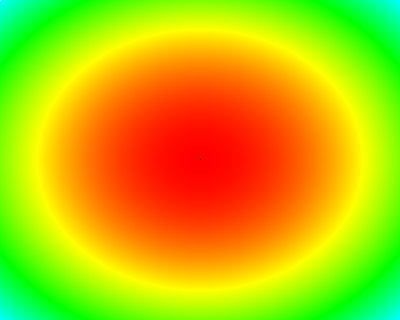
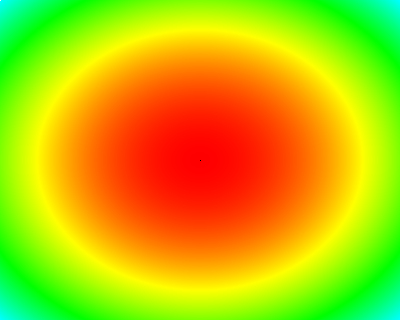

  f(1,1) = -2   f_rot = -2   ecart = 2,2E-16


  f(-2,3) = -13   f_rot = -13   ecart = 0


  f(0,5,-0,5) = -0,5   f_rot = -0,5   ecart = 5,6E-17


In [2]:
IFitness sphere = new SphereFitness();
double[,] Q = RotationMatrices.Seeded(2, 42);          // produit de Givens, M*M^T = I
IFitness sphereRot = new RotatedFitness(sphere, Q);

Console.WriteLine($"Q orthogonale ? {RotationMatrices.IsOrthogonal(Q)}  (produit de rotations de Givens).");

var bounds = (lo, hi);
byte[] pngSphere    = SkiaLandscapeRenderer.RenderHeatmapPng(Field(sphere),    bounds, bounds, 400, 320);
byte[] pngSphereRot = SkiaLandscapeRenderer.RenderHeatmapPng(Field(sphereRot), bounds, bounds, 400, 320);
ShowPair(pngSphere, "Sphere (axes canoniques)", pngSphereRot, "Sphere rotatée (Seeded 2,42)");

// Sanity numérique : en tout point, f_rot(x) == f(x) à 1e-9 près (invariance par rotation).
double[][] probes = { new[]{1.0,1.0}, new[]{-2.0,3.0}, new[]{0.5,-0.5} };
foreach (var p in probes)
    Console.WriteLine($"  f({p[0]:G3},{p[1]:G3}) = {Field(sphere)(p):G6}   f_rot = {Field(sphereRot)(p):G6}   ecart = {Math.Abs(Field(sphere)(p)-Field(sphereRot)(p)):G2}");


**Lecture.** Les deux cartes de chaleur sont identiques et l'écart numérique est nul (~1e-15) : la rotation est bien un no-op sur Sphere. C'est le témoin qui valide le décorateur — toute différence observée plus loin provient bien de la géométrie de la fonction, pas d'un bug de rotation.


---
## Partie C — La vallée banane pivote : Rosenbrock rotatée

Rosenbrock est l'archétype de la fonction *non* invariante par rotation : son optimum (valeur 0) est en $(1,1)$ et la « vallée banane » courbe longe l'axe $x$. On rotatée de $45°$ avec $M=[[c,-s],[s,c]]$, $c=s=\sqrt2/2$. L'optimum se déplace alors en $M^\top(1,1)=(\sqrt2, 0)$ et la vallée pivote hors des axes — un optimiseur axe-par-axe ne peut plus descendre un seul axe à la fois pour atteindre le fond de la vallée.


Rosenbrock (vallee banane axee) Rosenbrock rotatée 45° (vallee pivotee)
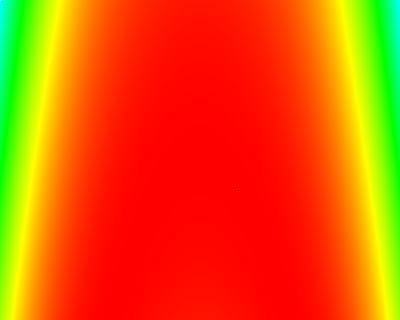
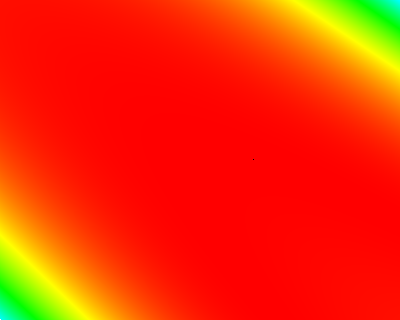

f_rot(sqrt2, 0) = -4,97968E-30   (optimum attendu ~0)


f_rot(1, 1)     = -201   (<0 : (1,1) n'est plus l'optimum)


In [3]:
IFitness rosen = new RosenbrockFitness();
double c = Math.Sqrt(2.0)/2.0;
double[,] M45 = new[,] { { c, -c }, { c, c } };          // rotation 45°
IFitness rosenRot = new RotatedFitness(rosen, M45);

var bounds = (lo, hi);
byte[] pngRosen    = SkiaLandscapeRenderer.RenderHeatmapPng(Field(rosen),    bounds, bounds, 400, 320);
byte[] pngRosenRot = SkiaLandscapeRenderer.RenderHeatmapPng(Field(rosenRot), bounds, bounds, 400, 320);
ShowPair(pngRosen, "Rosenbrock (vallee banane axee)", pngRosenRot, "Rosenbrock rotatée 45° (vallee pivotee)");

// Vérification : l'optimum rotaté est en M^T*(1,1) = (sqrt2, 0), valeur 0 ; (1,1) n'est plus optimal.
Console.WriteLine($"f_rot(sqrt2, 0) = {Field(rosenRot)(new[]{Math.Sqrt(2.0),0.0}):G6}   (optimum attendu ~0)");
Console.WriteLine($"f_rot(1, 1)     = {Field(rosenRot)(new[]{1.0,1.0}):G6}   (<0 : (1,1) n'est plus l'optimum)");


**Lecture.** La vallée courbe est visiblement **inclinée** après rotation : le fond de la vallée ne suit plus un axe. C'est précisément ce qui casse la séparabilité — il n'existe plus de $g(x)+h(y)$, un terme croisé $xy$ est apparu. Un croisement ou une mutation qui ne touche qu'un gène à la fois (axis-aligned) suit désormais une trajectoire oblique par rapport à la vallée et la descente devient inefficace.


---
## Partie D — Les crêtes cosinus basculent : Rastrigin rotatée (le lien avec MGS-12)

Rastrigin ajoute à Sphere une modulation cosinus **par axe** : $f(x,y)=\sum_i [x_i^2 - 10\cos(x_i)] + 20$. Les crêtes sont donc alignées avec les axes canoniques. Après rotation, ces crêtes **basculent** hors de la grille — et c'est exactement la signature numérique mesurée en MGS-12 : le GA axis-aligned perd ~+2847 sur Rastrigin rotatée (il échantillonne une grille qui ne « voit » plus la structure des crêtes), quand le DE rotation-robuste ne perd qu'~+2.


Rastrigin (cretes axees) Rastrigin rotatée (cretes basculees)
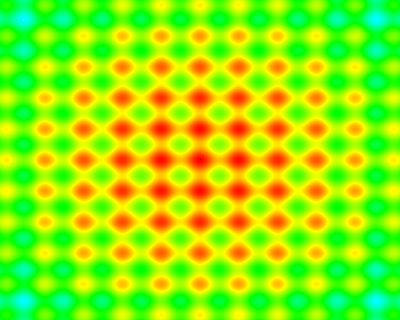
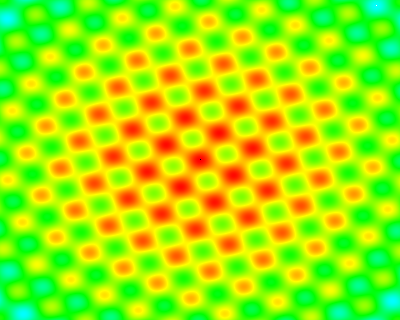

Comparer avec MGS-12 : le GA axis-aligned perd ~+2847 sur Rastrigin rotatée, le DE ~+2.


Le visuel ci-contre explique le *pourquoi* : la grille d'echantillonnage axe-par-axe ne suit plus les cretes.


In [4]:
IFitness rast = new RastriginFitness();
double[,] Qr = RotationMatrices.Seeded(2, 42);
IFitness rastRot = new RotatedFitness(rast, Qr);

var bounds = (lo, hi);
byte[] pngRast    = SkiaLandscapeRenderer.RenderHeatmapPng(Field(rast),    bounds, bounds, 400, 320);
byte[] pngRastRot = SkiaLandscapeRenderer.RenderHeatmapPng(Field(rastRot), bounds, bounds, 400, 320);
ShowPair(pngRast, "Rastrigin (cretes axees)", pngRastRot, "Rastrigin rotatée (cretes basculees)");

Console.WriteLine("Comparer avec MGS-12 : le GA axis-aligned perd ~+2847 sur Rastrigin rotatée, le DE ~+2.");
Console.WriteLine("Le visuel ci-contre explique le *pourquoi* : la grille d'echantillonnage axe-par-axe ne suit plus les cretes.");


**Lecture.** À gauche, les crêtes cosinus forment une grille régulière alignée sur les axes — un GA qui échantillonne selon les axes « tombe » naturellement dans la structure. À droite, la grille est **oblique** : un échantillonnage axe-par-axe coupe les crènes en biais et la structure régulière disparaît de son point de vue. C'est le mécanisme géométrique derrière le $\Delta$ numérique de MGS-12, rendu visible.


---
## Partie E — Composition CEC : déplacement *puis* rotation

Les benchmarks CEC combinent les deux biais : on **déplace** d'abord l'optimum hors du centre (`ShiftedFitness`), puis on **rotatée** (`RotatedFitness`). La composition `new RotatedFitness(new ShiftedFitness(inner, offset), M)` applique $f'(x)=f(Mx - o)$ : l'optimum atterrit en $M^\top o$ et le paysage est à la fois déplacé et incliné. Double dé-biais — central-bias *et* axis-alignment neutralisés d'un coup.


ShiftedFitness(Sphere,(2,0)) puis RotatedFitness(Seeded 2,7) -- optimum en M^T*(2,0)
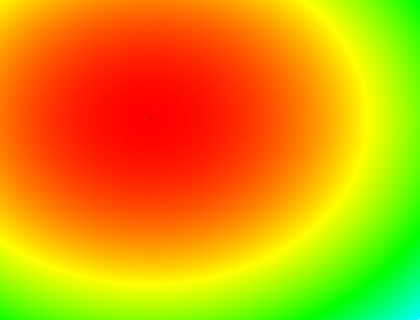

x* = M^T*offset = (-1,485, -1,339)   (offset=(2,0) rotaté)


f'(x*) = -4,93038E-32   (proche de 0 = optimum combine)


In [5]:
double[] offset = { 2.0, 0.0 };                            // déplace l'optimum de Sphere
double[,] Mce = RotationMatrices.Seeded(2, 7);
IFitness cec = new RotatedFitness(new ShiftedFitness(new SphereFitness(), offset), Mce);

var bounds = (lo, hi);
byte[] pngCec = SkiaLandscapeRenderer.RenderHeatmapPng(Field(cec), bounds, bounds, 420, 320);
ShowPng(pngCec, "ShiftedFitness(Sphere,(2,0)) puis RotatedFitness(Seeded 2,7) -- optimum en M^T*(2,0)", 440);

// Optimum combiné : f'(x)=Sphere(M x - o) est optimale en x = M^{-1} o = M^T o (M orthogonale).
// Produit matrice-vecteur explicite M^T o pour ne pas confondre ligne et colonne.
double[] xStar = { Mce[0,0]*offset[0] + Mce[1,0]*offset[1],   // (M^T o)_0
                  Mce[0,1]*offset[0] + Mce[1,1]*offset[1] };  // (M^T o)_1
Console.WriteLine($"x* = M^T*offset = ({xStar[0]:G4}, {xStar[1]:G4})   (offset=(2,0) rotaté)");
Console.WriteLine($"f'(x*) = {Field(cec)(xStar):G6}   (proche de 0 = optimum combine)");


**Lecture.** Le puits de Sphere n'est plus au centre (central-bias vaincu) ni aligné sur les axes (axis-alignment vaincu). Un optimiseur qui démarre systématiquement de l'origine ou qui optimise axe par axe est doublement pénalisé — c'est le niveau de robustesse exigé par les suites CEC modernes.


---
## Conclusion

La rotation n'est pas un caprice de benchmark : c'est un **test de séparabilité**. Trois images le résument :

1. **Sphere rotatée = Sphere** : une fonction invariante par rotation ignore le changement de repère — le témoin de contrôle.
2. **Rosenbrock rotatée** : la vallée banane pivote, l'optimum déménage, un terme croisé apparaît — la séparabilité est détruite.
3. **Rastrigin rotatée** : les crêtes cosinus basculent hors de la grille d'échantillonnage axe-par-axe — le mécanisme géométrique derrière le $\Delta\approx+2847$ du GA mesuré en MGS-12.

Là où MGS-12 *quantifie* la perte de fitness des métaheuristiques axis-aligned, ce notebook la *montre*. Les décorateurs `ShiftedFitness` / `RotatedFitness` rendent ces transformations compositionnelles et réutilisent les fonctions canoniques sans les réimplémenter — la transparence requise pour qu'un benchmark soit honnête (cf. Sørensen 2015, « components over metaphors »).

> Suite logique : combiner ce diagnostic visuel avec un *repair* axis-alignment (estimer $M$ depuis les données puiscontre-rotater), ou comparer les paysages de-biaisés sur d'autres fonctions (Ackley, Schwefel) — voir les exercices.


---
## Exercices

> Rappel (convention C.1) : les cellules ci-dessous sont des **stubs** à compléter. Elles s'exécutent sans erreur (`return null` / TODO), le notebook reste valide de bout en bout.


### Exercice 1 — Ackley rotatée

Ackley a une structure de « cratère » avec des ondulations concentriques. Rendez son paysage avant/après rotation par `RotationMatrices.Seeded(2, 42)` et observez si les ondulations restent concentriques (invariantes) ou se déforment. Complétez le stub.

In [6]:
// Exercice 1 : rendre Ackley puis Ackley rotatée côte à côte (cf. Partie D pour le modèle).
// Indice : new AckleyFitness() ; Field(f) ; ShowPair(...). Interprétez ensuite l'effet de la rotation.
public (byte[] plain, byte[] rotated) RenderAckleyPair()
{
    // TODO étudiant : construire ackley + ackleyRot, rendre les deux PNG, les retourner.
    return (null, null);  // TODO etudiant
}

// Décommentez après completion :
// var (aPlain, aRot) = RenderAckleyPair();
// ShowPair(aPlain, "Ackley", aRot, "Ackley rotatée");


### Exercice 2 — Retrouver l'optimum déplacé numériquement

Pour Rosenbrock rotatée 45°, l'optimum théorique est en $(\sqrt2, 0)$. Retrouvez-le **numériquement** par une simple recherche sur grille (pas d'optimiseur) : balayez $[-5,5]^2$ par pas de 0.1 et retournez le point de fitness maximale. Vérifiez qu'il est proche de $(\sqrt2, 0)\approx(1.414, 0)$.

In [7]:
// Exercice 2 : recherche sur grille de l'optimum de Rosenbrock rotatée 45°.
// Indice : DoubleArrayChromosome + Field(rosenRot) ; double for sur x,y par pas 0.1 ; garder le max.
public double[] GridArgmax(Func<double[], double> field, double lo, double hi, double step)
{
    // TODO etudiant : parcourir la grille, retourner le (x,y) de fitness maximale.
    return null;  // TODO etudiant
}

// Décommentez après completion :
// double[] opt = GridArgmax(Field(new RotatedFitness(new RosenbrockFitness(), new[,]{{c,-c},{c,c}})), -5, 5, 0.1);
// Console.WriteLine($"optimum numerique = ({opt[0]:G4}, {opt[1]:G4})  (theorique (sqrt2,0) ~ (1.414, 0))");


### Exercice 3 — Composition CEC sur une autre fonction

Appliquez la composition `RotatedFitness(ShiftedFitness(inner, offset), M)` à **Schwefel** (dont l'optimum n'est pas au centre même non déplacé). Rendez le paysage et commentez : où atterrit l'optimum combiné, et la vallée est-elle reconnaissable ?

In [8]:
// Exercice 3 : rendre Schwefel shift+rotate.
// Indice : new SchwefelFitness() ; choisir un offset non nul et une RotationMatrices.Seeded(2, seed).
public byte[] RenderSchwefelShiftedRotated()
{
    // TODO étudiant : composer ShiftedFitness puis RotatedFitness, rendre le PNG.
    return null;  // TODO etudiant
}

// Décommentez après completion :
// ShowPng(RenderSchwefelShiftedRotated(), "Schwefel shift+rotate");
